In [2]:
import optuna
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold,cross_validate
print(optuna.__version__)
from sklearn.ensemble import RandomForestRegressor as RFR

import matplotlib.pyplot as plt


4.2.1


In [3]:
count = 0
results=[]

In [4]:
def plot_distribution(data):
    # 设置图片清晰度
    plt.rcParams['figure.dpi'] = 300

    # 绘制直方图
    plt.hist(data, bins=200, edgecolor='black')

    # 添加图标题和坐标轴标签
    plt.title('Distribution of Values')
    plt.xlabel('Value')
    plt.xticks(rotation=45)
    plt.ylabel('Frequency')

    # 显示图形
    plt.show()

In [5]:
# Define the target function
def target_function(p1, p2, p3, p4, p5, p6):
    global count  # Declare count as global   
    count = count + 1
    return (p1 * p2) / p3 + p4/p5 + p6 
    # return p1+p2+p3+p4+p5+p6

In [6]:
def optuna_objective(trial) :
    # 定义参数空间
    p1 = trial.suggest_int('p1',1,100)
    p2 = trial.suggest_int('p2',1,100)
    p3 = trial.suggest_int('p3',1,100)
    p4 = trial.suggest_int('p4',1,100)
    p5 = trial.suggest_int('p5',1,100)
    p6 = trial.suggest_int('p6',1,100)

    target_value = target_function(p1, p2, p3, p4, p5, p6)
    # 计算目标函数值

    global results
    results.append(target_value)

    return target_value


In [7]:
def optimizer_optuna(n_trials,algo):
 
    # 定义使用TPE或GP
    if algo == 'TPE':
        algo = optuna.samplers.TPESampler(n_startup_trials=20,n_ei_candidates=30)
        # algo = optuna.samplers.TPESampler()
    elif algo == 'GP':
        from optuna.integration import SkoptSampler
        import skopt
        algo = SkoptSampler(skopt_kwargs={'base_estimator':'GP',
                                          'n_initial_points':10,
                                          'acq_func':'EI'})
    study = optuna.create_study(sampler=algo,direction='maximize')
    study.optimize(optuna_objective,n_trials=n_trials,show_progress_bar=True)
 
    print('best_params:',study.best_trial.params,
              'best_score:',study.best_trial.values,
              '\n')
 
    return study.best_trial.params, study.best_trial.values


In [ ]:
import warnings

count = 0
results=[]

warnings.filterwarnings('ignore',message='The objective has been evaluated at this point before trails')
optuna.logging.set_verbosity(optuna.logging.ERROR)
best_params, best_score = optimizer_optuna(10,'TPE')
print("count 的值:", count)

  0%|          | 0/10 [00:00<?, ?it/s]

best_params: {'p1': 85, 'p2': 36, 'p3': 20, 'p4': 47, 'p5': 31, 'p6': 93} best_score: [247.51612903225808] 



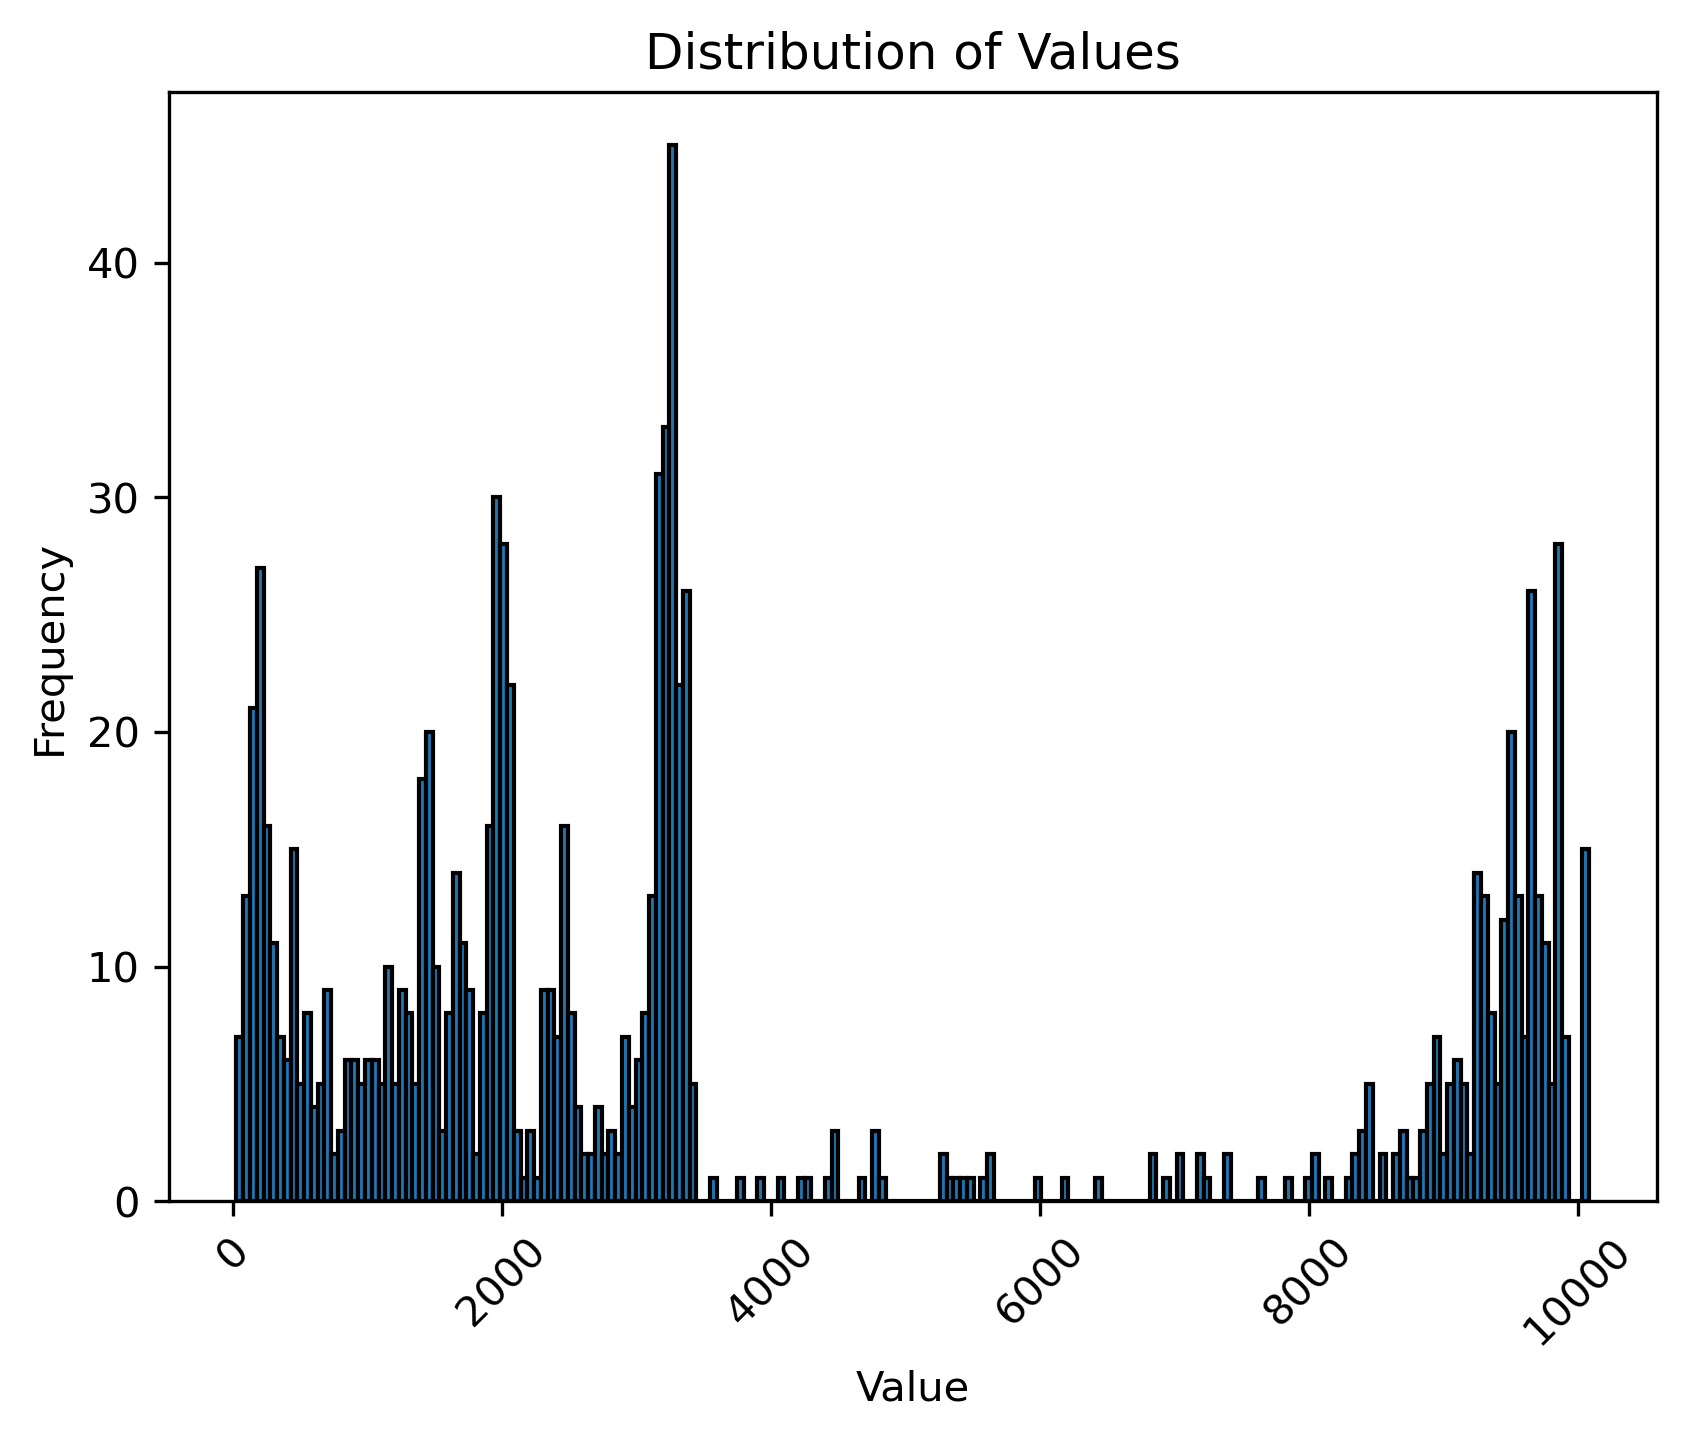

In [98]:
# 调用函数绘制分布图
plot_results = np.array(results)
plot_distribution(plot_results)